 تم دمج البيانات بنجاح! الإجمالي الآن: 3650814 صف.


,Column1,date_,user_id_maped,program_name,duration_seconds,program_class,season,episode,program_desc,program_genre,series_title,hd,original_name,Unnamed: 0,Total_watch_time_in_houres,rating
0,1,2017-05-27,26138,100 treets,40,MOVIE,0,0,Drama Movie100 Streets,Drama,0,0,100 treets,NaN,NaN,1.0
1,3,2017-05-21,7946,Moana,17,MOVIE,0,0,Animation MovieMoana (HD),Animation,0,1,Moana,NaN,NaN,NaN
2,4,2017-08-10,7418,The Mermaid Princess,8,MOVIE,0,0,Animation MovieThe Mermaid Princess (HD),Animation,0,1,The Mermaid Princess,NaN,NaN,NaN
3,5,2017-07-26,19307,The Mermaid Princess,76,MOVIE,0,0,Animation MovieThe Mermaid Princess (HD),Animation,0,1,The Mermaid Princess,NaN,NaN,NaN
4,7,2017-07-07,15860,Churchill,87,MOVIE,0,0,Biography MovieChurchill (HD),Biography,0,1,Churchill,NaN,NaN,NaN


Correlation between HD and rating: 0.18
 متوسط التقييم بناءً على جودة المشاهدة 
              hd    rating
0  SD Experience  2.182048
1  HD Experience  2.787265


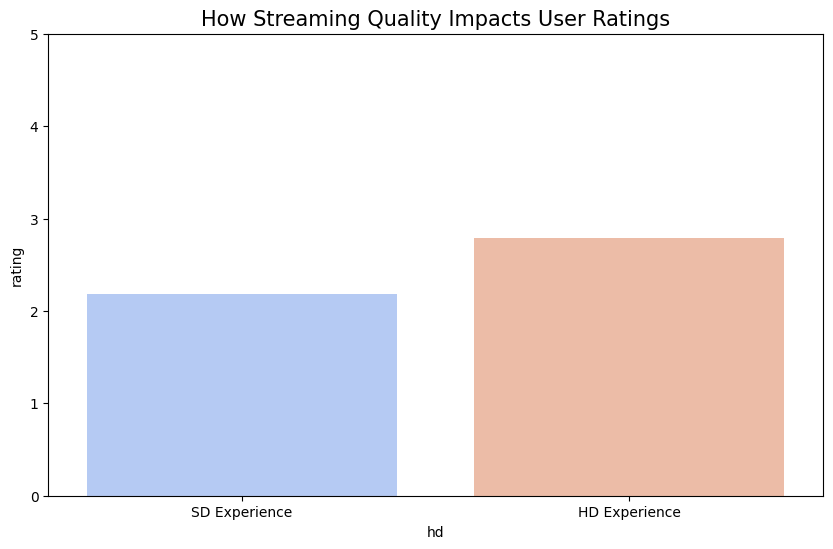

In [10]:


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df1 = pd.read_excel('stc TV Data Set_T1.xlsx') 
df2 = pd.read_excel('stc TV Data Set_T2.xlsx') 
df3 = pd.read_excel('stc TV Data Set_T3.xlsx') 

# --- (Data Integration) ---

merged_df = pd.merge(df1, df2, on='date_', how='left')
merged_df = pd.merge(merged_df, df3[['user_id_maped', 'program_name','rating']],
                     on=['user_id_maped', 'program_name'], 
                     how='left')

merged_df['duration_seconds'] = pd.to_numeric(merged_df['duration_seconds'], errors='coerce')
merged_df = merged_df.dropna(subset=['duration_seconds']) 
merged_df = merged_df [merged_df['duration_seconds']< 43200]
print(f" تم دمج البيانات بنجاح! الإجمالي الآن: {merged_df.shape[0]} صف.")
display(merged_df.head())

# هل جودة البث تؤثر على تقييم المستخدم؟
impact_analysis = merged_df.groupby('hd')['rating'].mean().reset_index()
impact_analysis['hd'] = impact_analysis['hd'].map({1: 'HD Experience', 0: 'SD Experience'})
print (f"Correlation between HD and rating: {merged_df[['hd','rating']].corr().iloc[0,1]:.2f}")
print(" متوسط التقييم بناءً على جودة المشاهدة ")
print(impact_analysis)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=impact_analysis, x='hd', y='rating', hue='hd', palette='coolwarm', legend=False)
plt.title('How Streaming Quality Impacts User Ratings', fontsize=15)
plt.ylim(0, 5) 
plt.show()


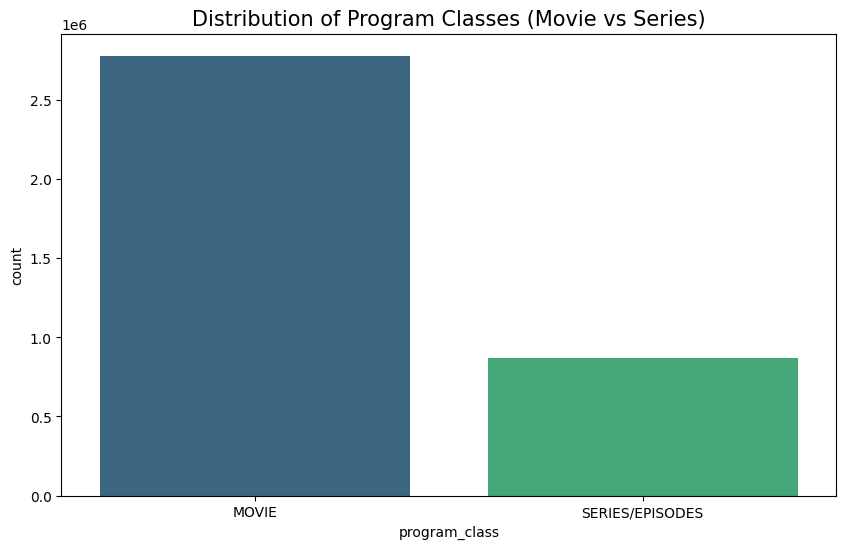

متوسط مدة المشاهدة (بالدقائق) 
program_class
MOVIE               5.508551
SERIES/EPISODES    20.267469
Name: duration_seconds, dtype: float64


In [11]:
# تحليل توزيع المشاهدات بين الأفلام والمسلسلات
plt.figure(figsize=(10, 6))
sns.countplot(data=merged_df, x='program_class', hue='program_class', palette='viridis')
plt.title('Distribution of Program Classes (Movie vs Series)', fontsize=15)
plt.show()

# حساب متوسط مدة المشاهدة لكل فئة بالدقائق
avg_duration = merged_df.groupby('program_class')['duration_seconds'].mean() / 60
print("متوسط مدة المشاهدة (بالدقائق) ")
print(avg_duration)


In [12]:
# تحليل نمط المشاهدة عبر الزمن

merged_df['date_'] = pd.to_datetime(merged_df['date_'])
merged_df['day_name'] = merged_df['date_'].dt.day_name()
viz_time = merged_df.groupby('day_name')['duration_seconds'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
print("Average view duration per day:\n", viz_time)

Average view duration per day:
 day_name
Monday       692.359165
Tuesday      534.890445
Wednesday    753.042600
Thursday     821.577448
Friday       386.935395
Saturday     430.087579
Sunday       563.087928
Name: duration_seconds, dtype: float64


In [13]:
# 1. تجميع البيانات وحساب المتوسطات
engagement_analysis = merged_df.groupby(['program_class', 'hd']).agg({
    'duration_seconds': 'mean',
    'user_id_maped': 'nunique'
}).reset_index()

# 2. تحويل الثواني لدقائق
engagement_analysis['avg_min'] = engagement_analysis['duration_seconds'] / 60

# 3. طباعة الجدول
print(engagement_analysis)


     program_class  hd  duration_seconds  user_id_maped    avg_min
0            MOVIE   0        296.607634           6088   4.943461
1            MOVIE   1        581.051494          10875   9.684192
2  SERIES/EPISODES   0       1309.985947           3281  21.833099
3  SERIES/EPISODES   1        870.576619           2623  14.509610


In [14]:
# 1. تعريف دالة التقسيم بناءً على مدة المشاهدة بالثواني
def segment_logic(seconds):
    if seconds > 1200: # أكثر من 20 دقيقة
        return 'Binge Watcher (Loyal)'
    elif seconds > 300: # بين 5 و 20 دقيقة
        return 'Casual Viewer'
    else:
        return 'Short Session'

# 2. تطبيق التقسيم على كل مستخدم
user_segments = merged_df.groupby('user_id_maped')['duration_seconds'].mean().apply(segment_logic)

# 3. طباعة النتائج النهائية
print("--- توزيع فئات المستخدمين لـ stc tv ---")
print(user_segments.value_counts())


--- توزيع فئات المستخدمين لـ stc tv ---
duration_seconds
Short Session            7355
Casual Viewer            2162
Binge Watcher (Loyal)    2055
Name: count, dtype: int64


In [15]:
# تحديد البرامج التي تسببت في نفور المشاهدين (مشاهدة أقل من 5 دقائق وتقييم سيء)
failed_content = merged_df[(merged_df['duration_seconds'] < 300) & (merged_df['rating'] <= 2)]

print("--- تحليل المحتوى الضعيف (High Churn) ---")
print(f"عدد البرامج التي لم يكملها المستخدمون وقيموها بسوء: {failed_content['program_name'].nunique()}")

# عرض أكثر 5 برامج تكرر فيها هذا السلوك
print("\nأكثر 5 برامج تسببت في ارتداد المشاهدين:")
print(failed_content['program_name'].value_counts().head(5))


--- تحليل المحتوى الضعيف (High Churn) ---
عدد البرامج التي لم يكملها المستخدمون وقيموها بسوء: 3037

أكثر 5 برامج تسببت في ارتداد المشاهدين:
program_name
Rebel in the Rye     532213
Bad Teacher          259310
Marshall             222541
The ocial Network     98768
Coco                  69861
Name: count, dtype: int64


### Strategic Insights & Business Recommendations

* **1. Quality Impact:** There is a positive correlation between **HD usage and user ratings**. Upgrading SD content to HD should be a top priority to drive satisfaction.
* **2. User Engagement:** **'Binge watchers'** are the most valuable segment. Loyalty programs and personalized push notifications should target this group to maintain retention.
* **3. Content Strategy:** Movies dominate the platform usage. Increasing the **Series Library** could convert 'Short Session' users into 'Binge Watchers' by encouraging continuous viewing.



In [16]:
merged_df.to_csv('stc_tv_final_data.csv', index=False)
print("CSV Exported successfully for Tableau!")

CSV Exported successfully for Tableau!
